In [133]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# Read input

In [134]:
FINDER = 'minimap2'
# FINDER = 'repeat-scout'
# FINDER = 'phraider'
# FINDER = 'total-repeats'

In [135]:
raw_infpath = '/mnt/data/Max/repos/reverlor/param_selection/test_repeat_detection/workdir_{}/repeat_detection_table_raw.tsv'.format(
    FINDER
)
detect_infpath = '/mnt/data/Max/repos/reverlor/param_selection/test_repeat_detection/workdir_{}/repeat_detection_table.tsv'.format(
    FINDER
)

In [136]:
df_raw = pl.read_csv(raw_infpath, separator='\t')
df_raw = df_raw.with_columns(
    (
        pl.col('repeat_len').cast(pl.String) \
        + '_' \
        + pl.col('repeat_idx').cast(pl.String) \
        + '_' \
        + pl.col('rate').cast(pl.String) \
    ).alias('repeat_id')
)
if FINDER == 'phraider':
    df = df.filter(
        ~(
            (pl.col('value_type') == 'true') & (pl.col('strand') == '-')
        )
    )
# end if
print(df_raw.shape)
df_raw.head()

(16278, 9)


chr,repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,strand,repeat_id
str,i64,i64,f64,str,i64,i64,str,str
"""replicon_1""",10000,0,0.0,"""true""",87045,97045,"""-""","""10000_0_0.0"""
"""replicon_2""",10000,0,0.0,"""true""",910,10910,"""-""","""10000_0_0.0"""
"""replicon_1""",10000,0,0.0,"""pred""",87045,97045,""".""","""10000_0_0.0"""
"""replicon_2""",10000,0,0.0,"""pred""",910,10910,""".""","""10000_0_0.0"""
"""replicon_1""",10000,0,0.01,"""true""",87045,97045,"""-""","""10000_0_0.01"""


In [137]:
true_df = df_raw.filter(
    pl.col('value_type') == 'true'
)

In [138]:
repeat_detect_df = pl.read_csv(
    detect_infpath,
    separator='\t',
    null_values=['NA', '', 'na']
)
print(repeat_detect_df.shape)
repeat_detect_df.head()

(8400, 10)


chr,repeat_id,true_start_coord,true_end_coord,pred_start_coord,pred_end_coord,repeat_detected,repeat_len,repeat_idx,rate
str,str,i64,i64,i64,i64,i64,i64,i64,f64
"""replicon_2""","""3000_96_0.01""",349,3349,348,3349,1,3000,96,0.01
"""replicon_2""","""10000_60_0.01""",1181,11181,1181,11181,1,10000,60,0.01
"""replicon_2""","""127_14_0.04""",1825,1952,null,null,0,127,14,0.04
"""replicon_2""","""127_79_0.0""",532,659,532,659,1,127,79,0.0
"""replicon_1""","""5000_49_0.05""",200325,205325,200325,205325,1,5000,49,0.05


# Inspection

In [139]:
repeat_detect_df.filter(
    (pl.col('rate') == 0.00) & (pl.col('repeat_len') == 500) & (pl.col('repeat_detected') != 1)
).sort(by='repeat_idx')

chr,repeat_id,true_start_coord,true_end_coord,pred_start_coord,pred_end_coord,repeat_detected,repeat_len,repeat_idx,rate
str,str,i64,i64,i64,i64,i64,i64,i64,f64


In [140]:
repeat_detect_df.filter(
    (pl.col('rate') == 0.00) & (pl.col('repeat_len') == 500) & (pl.col('repeat_idx') == 1)
).sort(by='repeat_idx')

chr,repeat_id,true_start_coord,true_end_coord,pred_start_coord,pred_end_coord,repeat_detected,repeat_len,repeat_idx,rate
str,str,i64,i64,i64,i64,i64,i64,i64,f64
"""replicon_2""","""500_1_0.0""",1704,2204,1704,2204,1,500,1,0.0
"""replicon_1""","""500_1_0.0""",130094,130594,130094,130594,1,500,1,0.0


In [141]:
df.filter(
    (pl.col('rate') == 0.00) & (pl.col('repeat_len') == 127) & (pl.col('repeat_idx') == 3)
).sort(by=['repeat_idx', 'value_type', 'start_coord'])

chr,repeat_len,repeat_idx,rate,value_type,start_coord,end_coord,strand,repeat_id
str,i64,i64,f64,str,i64,i64,str,str
"""replicon_2""",127,3,0.0,"""pred""",1248,1393,""".""","""127_3_0.0"""
"""replicon_1""",127,3,0.0,"""pred""",134051,134196,""".""","""127_3_0.0"""
"""replicon_1""",127,3,0.0,"""pred""",139924,140142,""".""","""127_3_0.0"""
"""replicon_2""",127,3,0.0,"""true""",1248,1375,"""+""","""127_3_0.0"""
"""replicon_1""",127,3,0.0,"""true""",134051,134178,"""+""","""127_3_0.0"""


In [142]:
# TODO: remove?
# N_repeats = true_df.filter(
#     pl.col('rate') == 0.0
# ).shape[0]
# print('N_repeats = {}'.format(N_repeats))

# per_rate_summary_df = repeat_detect_df.group_by('rate').agg(
#     pl.col('repeat_detected').sum().alias('repeat_detected_count')
# ).sort(by=['rate'])

# per_rate_summary_df = per_rate_summary_df.with_columns(
#     (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent')
# )

# per_rate_summary_df.head(10)

# Helper functions

In [143]:
def get_per_rate_df(repeat_detect_df, true_df, repeat_len=200):
    N_repeats = true_df.filter(
        (pl.col('repeat_len') == repeat_len) \
        & (pl.col('rate') == 0.0)
    ).height
    print('N_repeats = {}'.format(N_repeats))
    
    result_df = repeat_detect_df.filter(
        pl.col('repeat_len') == repeat_len
    ).unique(
        subset=['chr', 'repeat_id']
    ).group_by('rate').agg(
        pl.col('repeat_detected').sum().alias('repeat_detected_count')
    ).sort(by=['rate'])
    
    result_df = result_df.with_columns(
        (pl.col('repeat_detected_count') / N_repeats * 100.0).alias('repeat_detected_percent'),
        pl.lit(repeat_len).alias('repeat_len')
    ).with_columns(
        pl.min_horizontal(pl.col('repeat_detected_percent'), 100.0).alias('repeat_detected_percent')
    )

    return result_df
# end def

def get_per_rate_coord_diff_df(repeat_detect_df, true_df, repeat_len=200):

    tmp_df = repeat_detect_df.filter(
        (pl.col('repeat_len') == repeat_len) \
      & (pl.col('repeat_detected') == 1)
    ).with_columns(
        (pl.col('pred_start_coord') - pl.col('true_start_coord')).abs().alias('start_coord_diff'),
        (pl.col('pred_end_coord') - pl.col('true_end_coord')).abs().alias('end_coord_diff')
    ).with_columns(
        (pl.col('repeat_id') + '_' + pl.col('chr')).alias('repeat_id')
    )

    min_start_coord_diff_df = tmp_df.group_by('repeat_id') \
        .agg(pl.col('start_coord_diff').min())
    min_end_coord_diff_df = tmp_df.group_by('repeat_id') \
        .agg(pl.col('end_coord_diff').min())

    result_df = tmp_df.select(
        pl.col('chr', 'repeat_id', 'repeat_idx', 'rate')
    ).join(
        min_start_coord_diff_df,
        on='repeat_id',
        how='left'
    ).join(
        min_end_coord_diff_df,
        on='repeat_id',
        how='left'
    ).with_columns(
        (pl.col('start_coord_diff') + pl.col('end_coord_diff')).alias('coord_diff_sum'),
        pl.lit(repeat_len).alias('repeat_len')
    )

    return result_df
# end def

# Make total detection plot

In [144]:
per_rate_len127_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=127
)
per_rate_len200_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=200
)
per_rate_len500_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=500
)
per_rate_len1k_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=1000
)
per_rate_len10k_summary_df = get_per_rate_df(
    repeat_detect_df,
    true_df,
    repeat_len=10000
)
all_summary_df = pl.concat([
    per_rate_len127_summary_df,
    per_rate_len200_summary_df,
    per_rate_len500_summary_df,
    per_rate_len1k_summary_df,
    per_rate_len10k_summary_df,
])
all_summary_df = all_summary_df.with_columns(
    pl.col('repeat_len').cast(pl.String)
)
all_summary_df.head()

N_repeats = 200
N_repeats = 200
N_repeats = 200
N_repeats = 200
N_repeats = 200


rate,repeat_detected_count,repeat_detected_percent,repeat_len
f64,i64,f64,str
0.0,200,100.0,"""127"""
0.01,198,99.0,"""127"""
0.02,182,91.0,"""127"""
0.03,148,74.0,"""127"""
0.04,24,12.0,"""127"""


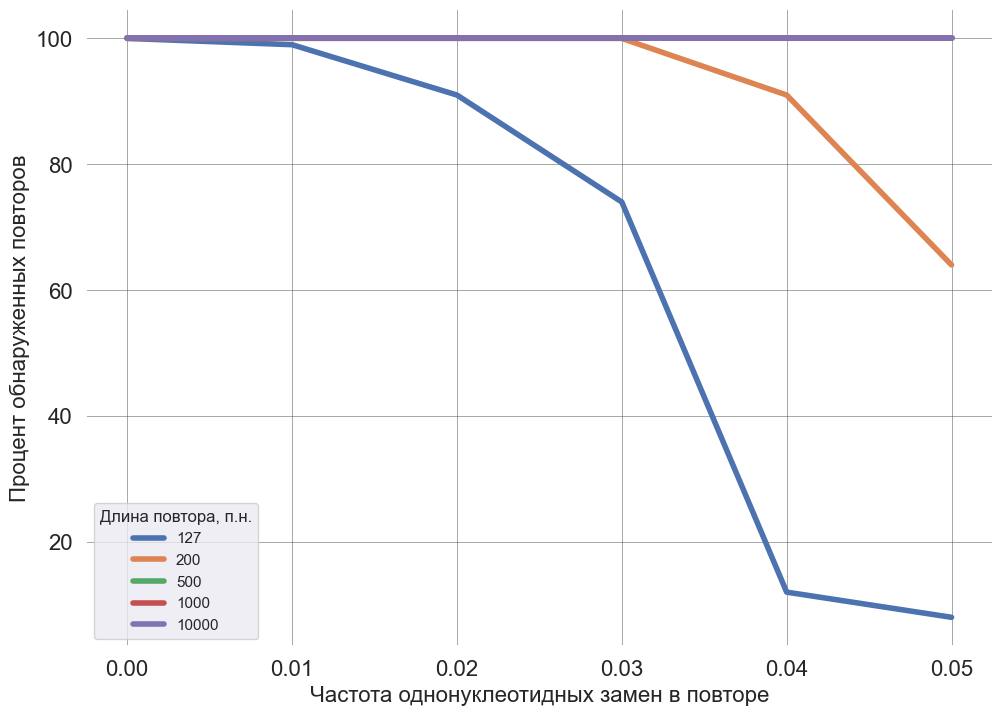

In [145]:
sns.set_theme(rc={'figure.figsize':(11.7,8.27)})

ax = sns.lineplot(
    all_summary_df,
    x='rate',
    y='repeat_detected_percent',
    hue='repeat_len',
    linewidth=4.0
)

ax.set_xlabel('Частота однонуклеотидных замен в повторе', fontsize=16)
ax.set_ylabel('Процент обнаруженных повторов', fontsize=16)

plt.legend(title='Длина повтора, п.н.')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

ax.grid(True, color='#505050', linestyle='-', linewidth=0.5, alpha=0.7)
ax.set_facecolor('#ffffff')

plt.show(ax)

# Make total coord diff plot

In [146]:
per_rate_len127_coord_diff_df = get_per_rate_coord_diff_df(
    repeat_detect_df,
    true_df,
    repeat_len=127
)
per_rate_len200_coord_diff_df = get_per_rate_coord_diff_df(
    repeat_detect_df,
    true_df,
    repeat_len=200
)
per_rate_len500_coord_diff_df = get_per_rate_coord_diff_df(
    repeat_detect_df,
    true_df,
    repeat_len=500
)
per_rate_len1k_coord_diff_df = get_per_rate_coord_diff_df(
    repeat_detect_df,
    true_df,
    repeat_len=1000
)
per_rate_len10k_coord_diff_df = get_per_rate_coord_diff_df(
    repeat_detect_df,
    true_df,
    repeat_len=10000
)

all_coord_df = pl.concat([
    per_rate_len127_coord_diff_df,
    per_rate_len200_coord_diff_df,
    per_rate_len500_coord_diff_df,
    per_rate_len1k_coord_diff_df,
    per_rate_len10k_coord_diff_df,
])
all_coord_df = all_coord_df.with_columns(
    pl.col('repeat_len').cast(pl.String)
)
all_coord_df.head()

chr,repeat_id,repeat_idx,rate,start_coord_diff,end_coord_diff,coord_diff_sum,repeat_len
str,str,i64,f64,i64,i64,i64,str
"""replicon_2""","""127_79_0.0_replicon_2""",79,0.0,0,0,0,"""127"""
"""replicon_1""","""127_42_0.02_replicon_1""",42,0.02,0,0,0,"""127"""
"""replicon_1""","""127_64_0.04_replicon_1""",64,0.04,0,0,0,"""127"""
"""replicon_1""","""127_67_0.02_replicon_1""",67,0.02,0,0,0,"""127"""
"""replicon_1""","""127_11_0.0_replicon_1""",11,0.0,1,1,2,"""127"""


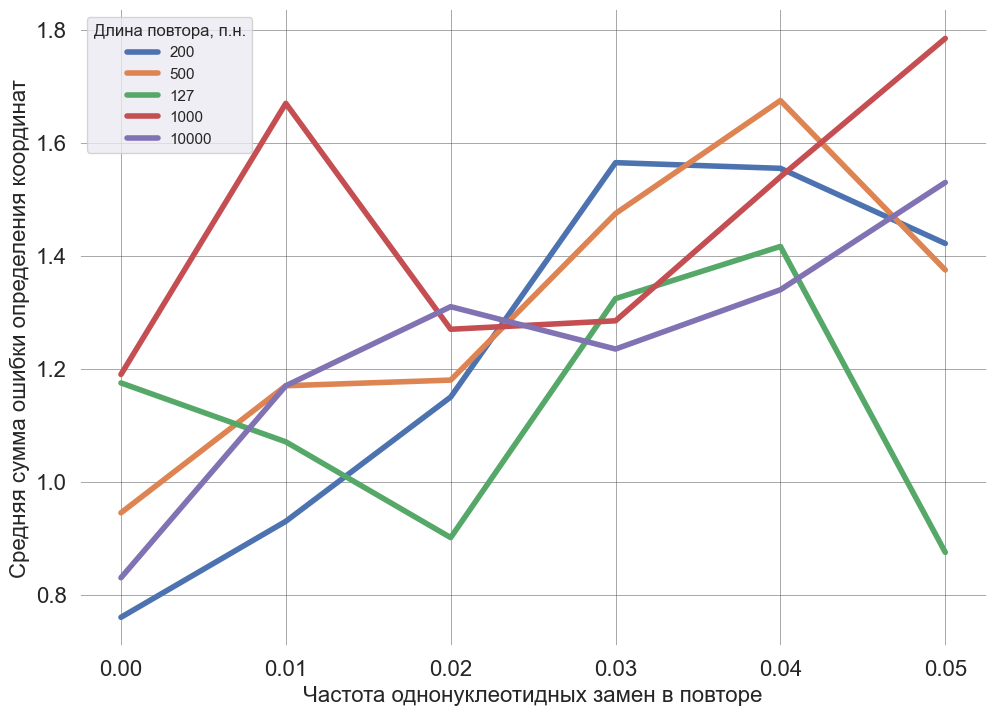

In [147]:
all_coord_mean_df = all_coord_df.group_by(['rate', 'repeat_len']) \
    .agg(pl.col('coord_diff_sum').mean().alias('mean_coord_diff_sum'))

sns.set_theme(rc={'figure.figsize':(11.7,8.27)})

ax = sns.lineplot(
    all_coord_mean_df,
    x='rate',
    y='mean_coord_diff_sum',
    hue='repeat_len',
    linewidth=4.0
)

ax.set_xlabel('Частота однонуклеотидных замен в повторе', fontsize=16)
ax.set_ylabel('Средняя сумма ошибки определения координат', fontsize=16)

plt.legend(title='Длина повтора, п.н.')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

ax.grid(True, color='#505050', linestyle='-', linewidth=0.5, alpha=0.7)
ax.set_facecolor('#ffffff')

plt.show(ax)

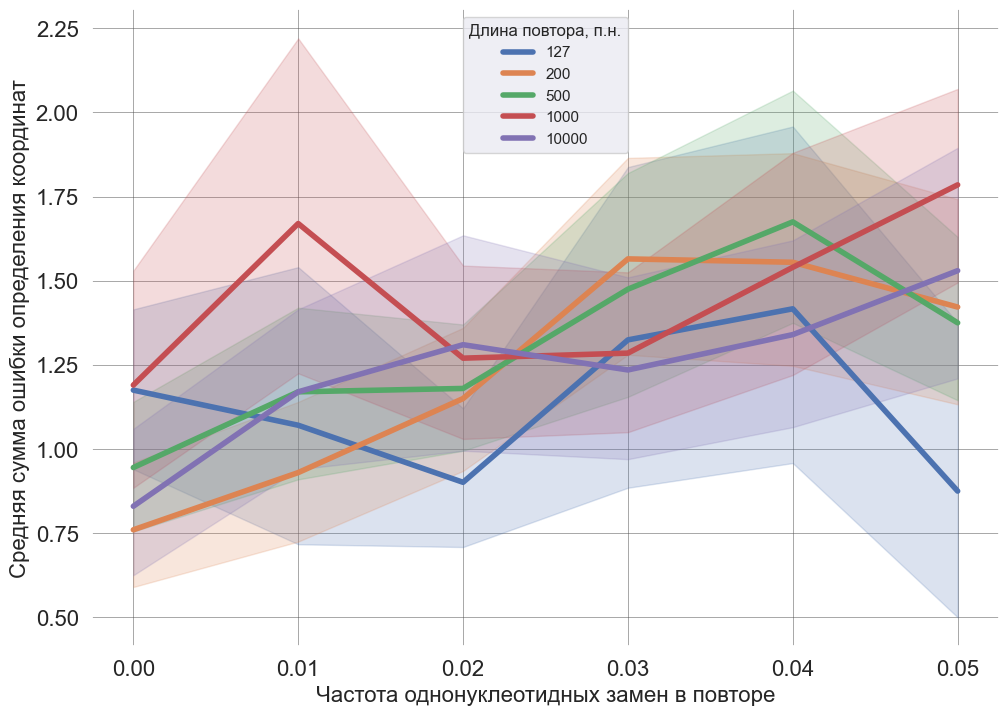

In [148]:
sns.set_theme(rc={'figure.figsize':(11.7,8.27)})

ax = sns.lineplot(
    all_coord_df,
    x='rate',
    y='coord_diff_sum',
    hue='repeat_len',
    linewidth=4.0,
    errorbar=('ci', 95)
)

ax.set_xlabel('Частота однонуклеотидных замен в повторе', fontsize=16)
ax.set_ylabel('Средняя сумма ошибки определения координат', fontsize=16)

plt.legend(title='Длина повтора, п.н.')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

ax.grid(True, color='#505050', linestyle='-', linewidth=0.5, alpha=0.7)
ax.set_facecolor('#ffffff')

plt.show(ax)

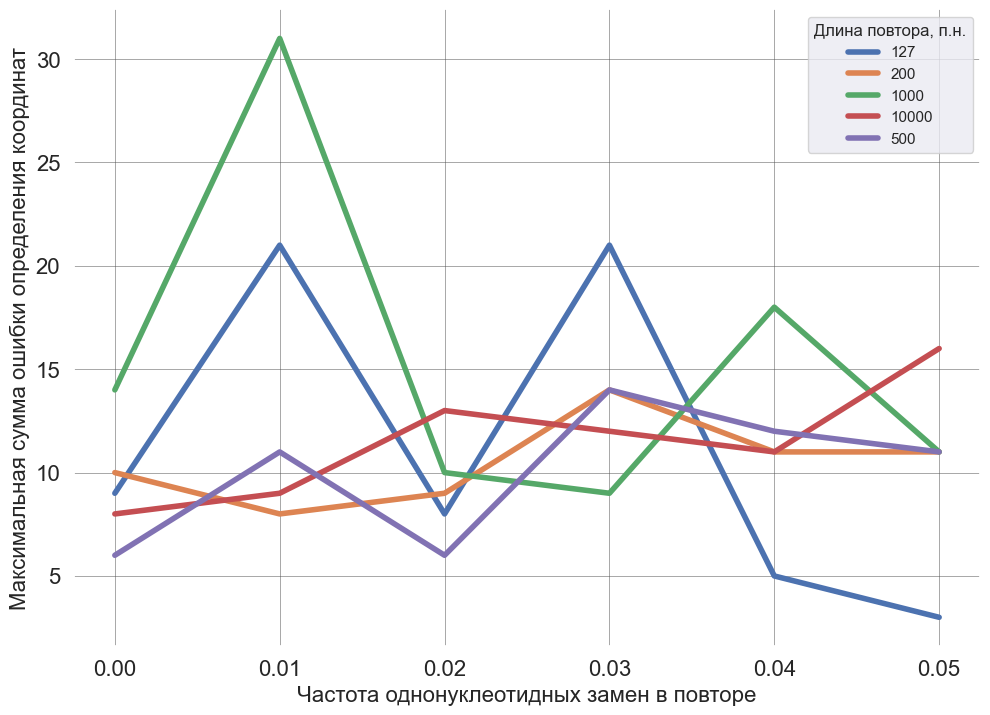

In [149]:
all_coord_mean_df = all_coord_df.group_by(['rate', 'repeat_len']) \
    .agg(pl.col('coord_diff_sum').max().alias('max_coord_diff_sum'))

sns.set_theme(rc={'figure.figsize':(11.7,8.27)})

ax = sns.lineplot(
    all_coord_mean_df,
    x='rate',
    y='max_coord_diff_sum',
    hue='repeat_len',
    linewidth=4.0
)

ax.set_xlabel('Частота однонуклеотидных замен в повторе', fontsize=16)
ax.set_ylabel('Максимальная сумма ошибки определения координат', fontsize=16)

plt.legend(title='Длина повтора, п.н.')

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

ax.grid(True, color='#505050', linestyle='-', linewidth=0.5, alpha=0.7)
ax.set_facecolor('#ffffff')

plt.show(ax)